# Início - Projeto Final - PGC201 Mineração de Dados (PPGCO/UFU)

# Bank Marketing - Análise Inicial dos Dados

> **Objetivo:** prever se um cliente de um banco português irá aderir a um depósito a prazo (tipo CDB) com base em atributos demográficos, de campanha e socioeconômicos

> **Dataset:** [Bank Marketing - UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)

> **Referência:** [Moro, S., Cortez, P., & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing.* Decision Support Systems, 62, 22-31.](https://doi.org/10.1016/j.dss.2014.03.001)

> **Versão:** `bank-additional-full.csv` (41.188 instâncias, 20 features + target)

## Sobre o Dataset

O dataset Bank Marketing foi coletado entre maio de 2008 e novembro de 2010, fruto de \
campanhas de telemarketing de um banco português. Cada instância representa uma ligação \
para um cliente, e o alvo (`y`) indica se o cliente subscreveu um depósito a prazo

> **Nota sobre `duration`:** conforme os próprios autores (Moro et al., 2014), a duração da ligação \
só é conhecida *após* a chamada encerrar. Incluí-la num modelo preditivo de produção seria data leakage. \
Vamos mantê-la na análise exploratória, porém treinaremos modelos **com e sem** ela para quantificar seu impacto.

> **Nota sobre `pdays`:** o valor 999 indica que o cliente nunca foi contactado anteriormente. Maneira engraçada \
de se colocar um indicativo, mas trataremos esse valor de forma especial durante o pré-processamento.

## Dicionário de Features

| #  | Feature          | Tipo        | Grupo                | Descrição                                                       | Valores/Observações                                                                                      |
|----|------------------|-------------|----------------------|-----------------------------------------------------------------|----------------------------------------------------------------------------------------------------------|
| 1  | `age`            | Numérica    | Cliente              | Idade do cliente                                                | Contínua (17-98)                                                                                         |
| 2  | `job`            | Categórica  | Cliente              | Tipo de emprego                                                 | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown |
| 3  | `marital`        | Categórica  | Cliente              | Estado civil                                                    | divorced, married, single, unknown                                                                       |
| 4  | `education`      | Categórica  | Cliente (ordinal)    | Nível de escolaridade                                           | basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown    |
| 5  | `default`        | Categórica  | Cliente              | Possui crédito em inadimplência?                                | no, yes, unknown                                                                                         |
| 6  | `housing`        | Categórica  | Cliente              | Possui financiamento imobiliário?                               | no, yes, unknown                                                                                         |
| 7  | `loan`           | Categórica  | Cliente              | Possui empréstimo pessoal?                                      | no, yes, unknown                                                                                         |
| 8  | `contact`        | Categórica  | Campanha atual       | Meio de contato                                                 | cellular, telephone                                                                                      |
| 9  | `month`          | Categórica  | Campanha atual       | Mês do último contato                                           | jan-dec (não é cíclico neste contexto)                                                                   |
| 10 | `day_of_week`    | Categórica  | Campanha atual       | Dia da semana do último contato                                 | mon, tue, wed, thu, fri                                                                                  |
| 11 | `duration`       | Numérica    | Campanha atual       | Duração da última ligação (segundos)                            | considerada Leakage - usar apenas para benchmark                                                     |
| 12 | `campaign`       | Numérica    | Campanha atual       | N.º de contatos nesta campanha                                  | Discreta (1-56)                                                                                          |
| 13 | `pdays`          | Numérica    | Campanha anterior    | Dias desde o último contato de campanha anterior                | 999 = nunca contactado                                                                                   |
| 14 | `previous`       | Numérica    | Campanha anterior    | N.º de contatos antes desta campanha                            | Discreta (0-7)                                                                                           |
| 15 | `poutcome`       | Categórica  | Campanha anterior    | Resultado da campanha anterior                                  | failure, nonexistent, success                                                                            |
| 16 | `emp.var.rate`   | Numérica    | Socioeconômico       | Taxa de variação do emprego (trimestral)                        | Contínua                                                                                                 |
| 17 | `cons.price.idx` | Numérica    | Socioeconômico       | Índice de preços ao consumidor (mensal)                         | Contínua                                                                                                 |
| 18 | `cons.conf.idx`  | Numérica    | Socioeconômico       | Índice de confiança do consumidor (mensal)                      | Contínua                                                                                                 |
| 19 | `euribor3m`      | Numérica    | Socioeconômico       | Taxa Euribor 3 meses (diária)                                  | Contínua                                                                                                 |
| 20 | `nr.employed`    | Numérica    | Socioeconômico       | N.º de empregados (trimestral, indicador macro)                 | Contínua                                                                                                 |
| -- | **`y`**          | **Target**  | --                   | Cliente subscreveu depósito a prazo?                            | yes / no (**~88% no, ~12% yes**)                                                                             |

# Configurações

In [1]:
%xmode plain

Exception reporting mode: Plain


In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr_or_assign"

# import warnings
# warnings.filterwarnings("ignore")

import pandas as pd
pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [4]:
# --- pré-processamento ---
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
# --- métricas ---
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    make_scorer
)

In [6]:
# --- classificadores ---
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [7]:
# --- feature selection ---
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel, mutual_info_classif

In [8]:
# --- tema visual ---
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

In [9]:
SEED = 42

42

---

# Carregando os Dados

In [10]:
# Opção 1: via ucimlrepo (pip install ucimlrepo)
#from ucimlrepo import fetch_ucirepo
#raw = fetch_ucirepo(id=222)
#df = pd.concat([raw.data.features, raw.data.targets], axis=1)

# Opção 2: download manual (maneira aqui utilizada)
# Baixe de https://archive.ics.uci.edu/dataset/222/bank+marketing
# Extraia bank-additional-full.csv para o diretório do notebook
df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=";")

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1000,93.9940,-36.4000,4.8570,5191.0000,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,4963.6000,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,4963.6000,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,4963.6000,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-1.1000,94.7670,-50.8000,1.0280,4963.6000,yes


---

# Distribuição da *target*

In [11]:
target_dist = df["y"].value_counts(normalize=True).rename("proporção")
print(f"Razão de desbalanceamento: {target_dist.iloc[0] / target_dist.iloc[1]:.2f}:1")

Razão de desbalanceamento: 7.88:1


In [12]:
target_dist.apply(lambda prop: f"{prop * 100:.2f}%").to_frame()

,proporção
y,
no,88.73%
yes,11.27%


---

# Tipos dos Dados

In [13]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [14]:
summary = pd.DataFrame({
    "Data.Type": df.dtypes,
    "N.Unique": df.nunique(),
    "Nulls": df.isnull().sum(),
    "Null.%": (df.isnull().sum() / len(df) * 100),
    "Sample": df.iloc[SEED]
})

,Data.Type,N.Unique,Nulls,Null.%,Sample
age,int64,78,0,0.0000,38
job,object,12,0,0.0000,admin.
marital,object,4,0,0.0000,single
education,object,8,0,0.0000,professional.course
default,object,3,0,0.0000,no
housing,object,3,0,0.0000,no
loan,object,3,0,0.0000,no
contact,object,2,0,0.0000,telephone
month,object,10,0,0.0000,may
day_of_week,object,5,0,0.0000,mon


## _Aside_: Otimizando os tipos

In [15]:
df[["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]].agg(['min', 'max'])

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
min,-3.4000,92.2010,-50.8000,0.6340,4963.6000
max,1.4000,94.7670,-26.9000,5.0450,5228.1000


In [16]:
cols = ["emp.var.rate", "cons.price.idx",
        "cons.conf.idx", "euribor3m",
        "nr.employed"]

for c in cols:
    err = (df[c] - df[c].astype(np.float32)).abs().max()
    print(c, err)

emp.var.rate 9.536743172944284e-08
cons.price.idx 3.662109378410605e-06
cons.conf.idx 1.5258789076710855e-06
euribor3m 2.2888183615066282e-07
nr.employed 0.00019531250018189894


In [17]:
for c in cols:
    err = (df[c] - df[c].astype(np.float16)).abs().max()
    print(c, err)

emp.var.rate 0.0003906250000000888
cons.price.idx 0.03100000000000591
cons.conf.idx 0.012500000000002842
euribor3m 0.0019375000000003695
nr.employed 1.5


Melhor jogar apenas pra `float32` mesmo

In [18]:
def optimize_dtypes(dataframe):
    """Reduz dtypes sem perda de precisão."""
    opt = dataframe.copy()

    for col in opt.select_dtypes(include=["float64"]).columns:
        opt[col] = opt[col].astype(np.float32)

    for col in opt.select_dtypes(include=["int64"]).columns:
        c_min, c_max = opt[col].min(), opt[col].max()
        if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
            opt[col] = opt[col].astype(np.int8)
        elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
            opt[col] = opt[col].astype(np.int16)
        elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
            opt[col] = opt[col].astype(np.int32)

    for col in opt.select_dtypes(include=["object"]).columns:
        opt[col] = opt[col].astype("category")

    return opt

In [19]:
before_mb = df.memory_usage(deep=True).sum() / 1024**2
df = optimize_dtypes(df)
after_mb = df.memory_usage(deep=True).sum() / 1024**2

print(f"Memória: {before_mb:.2f} MB → {after_mb:.2f} MB (redução de {(1 - after_mb / before_mb) * 100:.1f}%)")

Memória: 26.80 MB → 1.50 MB (redução de 94.4%)


In [20]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             41188 non-null  int8    
 1   job             41188 non-null  category
 2   marital         41188 non-null  category
 3   education       41188 non-null  category
 4   default         41188 non-null  category
 5   housing         41188 non-null  category
 6   loan            41188 non-null  category
 7   contact         41188 non-null  category
 8   month           41188 non-null  category
 9   day_of_week     41188 non-null  category
 10  duration        41188 non-null  int16   
 11  campaign        41188 non-null  int8    
 12  pdays           41188 non-null  int16   
 13  previous        41188 non-null  int8    
 14  poutcome        41188 non-null  category
 15  emp.var.rate    41188 non-null  float32 
 16  cons.price.idx  41188 non-null  float32 
 17  cons.conf.id

---

# Análise Exploratória de Dados (EDA)

A EDA segue duas etapas: primeiro olhamos cada feature isoladamente (**análise univariada**) pra entender \
distribuições, outliers e assimetrias; depois cruzamos cada feature com o target (**análise bivariada**) pra \
identificar quais variáveis diferenciam os grupos. Formalizamos as observações visuais com testes estatísticos.

> **Nota sobre testes com n grande:** com 41.188 amostras, praticamente qualquer diferença, \
por menor que seja, será estatisticamente significativa (p < 0.001). Por isso priorizamos \
**tamanhos de efeito** (rank-biserial *r* e *V* de Cramér) em vez de nos basearmos apenas em p-valores.

## Análise Univariada

### Estatísticas descritivas das features numéricas

In [21]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include="category").columns.drop("y").tolist()
print(f"Atributos numéricos ({len(num_cols)}): {num_cols}\nAtributos categóricos ({len(cat_cols)}): {cat_cols}")

Atributos numéricos (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Atributos categóricos (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [22]:
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurtosis()
desc["IQR"] = desc["75%"] - desc["25%"]
desc[["count", "mean", "std", "min", "25%", "50%", "75%", "max", "IQR", "skew", "kurtosis"]]

,count,mean,std,min,25%,50%,75%,max,IQR,skew,kurtosis
age,41188.0000,40.0241,10.4212,17.0000,32.0000,38.0000,47.0000,98.0000,15.0000,0.7847,0.7913
duration,41188.0000,258.2850,259.2792,0.0000,102.0000,180.0000,319.0000,4918.0000,217.0000,3.2631,20.2479
campaign,41188.0000,2.5676,2.7700,1.0000,1.0000,2.0000,3.0000,56.0000,2.0000,4.7625,36.9798
pdays,41188.0000,962.4755,186.9109,0.0000,999.0000,999.0000,999.0000,999.0000,0.0000,-4.9222,22.2295
previous,41188.0000,0.1730,0.4949,0.0000,0.0000,0.0000,0.0000,7.0000,0.0000,3.8320,20.1088
emp.var.rate,41188.0000,0.0819,1.5710,-3.4000,-1.8000,1.1000,1.4000,1.4000,3.2000,-0.7241,-1.0626
cons.price.idx,41188.0000,93.5757,0.5788,92.2010,93.0750,93.7490,93.9940,94.7670,0.9190,-0.2309,-0.8298
cons.conf.idx,41188.0000,-40.5026,4.6282,-50.8000,-42.7000,-41.8000,-36.4000,-26.9000,6.3000,0.3032,-0.3586
euribor3m,41188.0000,3.6213,1.7344,0.6340,1.3440,4.8570,4.9610,5.0450,3.6170,-0.7092,-1.4068
nr.employed,41188.0000,5167.0361,72.2515,4963.6001,5099.1001,5191.0000,5228.1001,5228.1001,129.0000,-1.0443,-0.0038


> Nota sobre Assimetria (Skewness) e Curtose (Kurtosis):

A assimetria (que é o 3º momento, vê-se pela fórmula) mede o grau de simetria da distribuição:

$$\gamma_1 = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^3$$

| Valor de $\gamma_1$ | Interpretação |
|---|---|
| $\approx 0$ | Distribuição simétrica |
| $> 0$ | Cauda à direita (right-skewed) |
| $< 0$ | Cauda à esquerda (left-skewed) |
| $\|\gamma_1\| > 1$ | Assimetria forte - considerar transformação (log, sqrt) |

A Curtose (*excess*) (vulgo 4º momento, vê-se pela fórmula novamente) mede o peso das caudas em relação à normal:

$$\gamma_2 = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

| Valor de $\gamma_2$ | Interpretação |
|---|---|
| $\approx 0$ | Mesocúrtica (caudas similares à normal) |
| $> 0$ | Leptocúrtica (caudas pesadas, pico mais agudo - mais outliers) |
| $< 0$ | Platicúrtica (caudas leves, formato mais achatado) |

O $-3$ subtrai a curtose da distribuição normal (que é 3), de modo que $\gamma_2 = 0$ indica comportamento "normal". O `pandas` e `scipy` já reportam essa versão *excess*.

### Distribuições das features numéricas (histograma e KDE)

O que é e por que utilizar KDE?

A KDE (*Kernel Density Estimation*) é uma estimativa não-paramétrica da função densidade de probabilidade \
Coloca-se um *kernel* suave (geralmente Gaussiano) sobre cada ponto e soma-se as contribuições:

$$\hat{f}(x) = \frac{1}{nh} \sum_{i=1}^{n} K\!\left(\frac{x - x_i}{h}\right)$$

onde $K$ é a função kernel e $h$ é a largura de banda (*bandwidth*). A vantagem sobre o histograma puro é que \
a KDE não depende da escolha de bins nem de bordas de intervalo, revelando de forma contínua a *forma real* da \
distribuição - modas, assimetrias e caudas ficam mais evidentes.

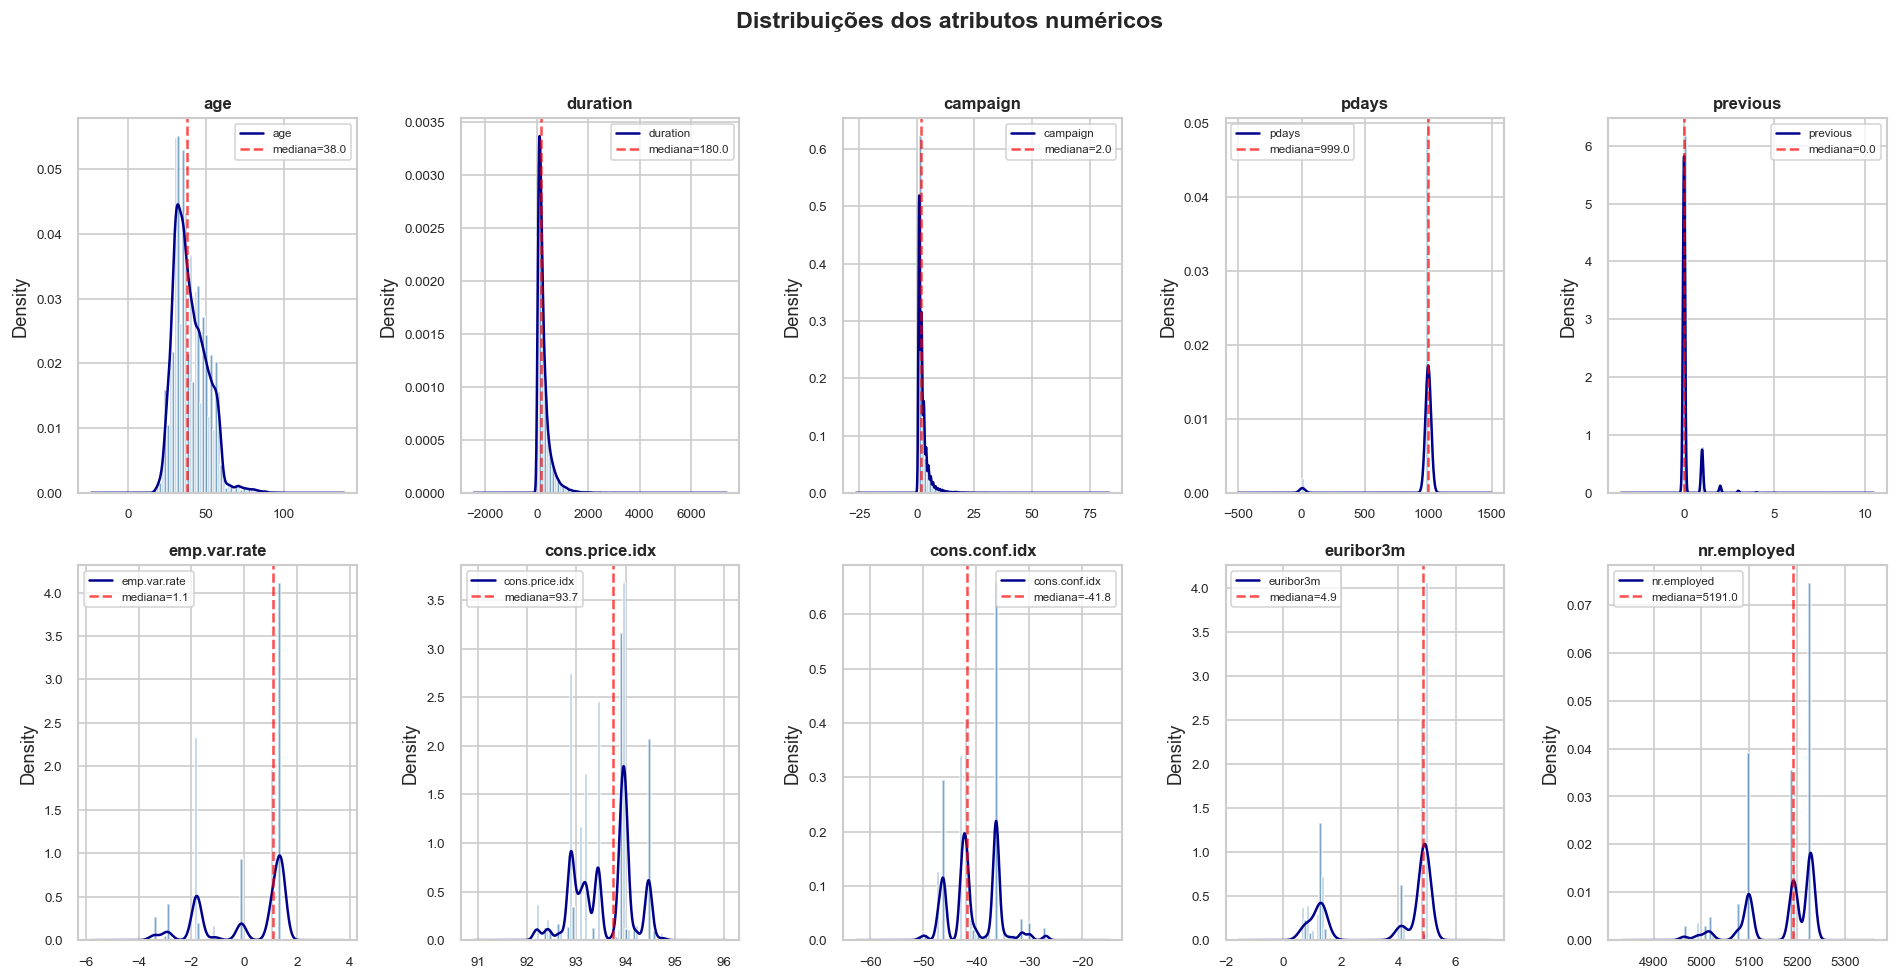

In [137]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle("Distribuições dos atributos numéricos", fontsize=14, fontweight="bold", y=1.02)

for ax, col in zip(axes.flat, num_cols):
    data = df[col]
    ax.hist(data, bins=50, edgecolor="white", alpha=0.7, density=True, color="steelblue")
    data.plot.kde(ax=ax, color="darkblue", linewidth=1.5)
    ax.axvline(data.median(), color="red", linestyle="--", alpha=0.7, label=f"mediana={data.median():.1f}")
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig("figures/dist_numericos.png", dpi=150, bbox_inches="tight")
plt.show()

Observações a registrar:
- Features com alta assimetria ($\text{skew} > |1|$) são candidatas a transformação logarítmica ou raiz
- `pdays` tem distribuição degenerada (maioria = 999, significando "nunca contactado") - precisará de tratamento especial
- `campaign` tem um início de cauda à direita e `previous` tem um padrão de gota d'água
- As socioeconômicas (`emp.var.rate`, `cons.price.idx`, etc.) tem poucos valores únicos pois são indicadores macroeconômicos compartilhados por todas as ligações num dado período

### Distribuições das features categóricas

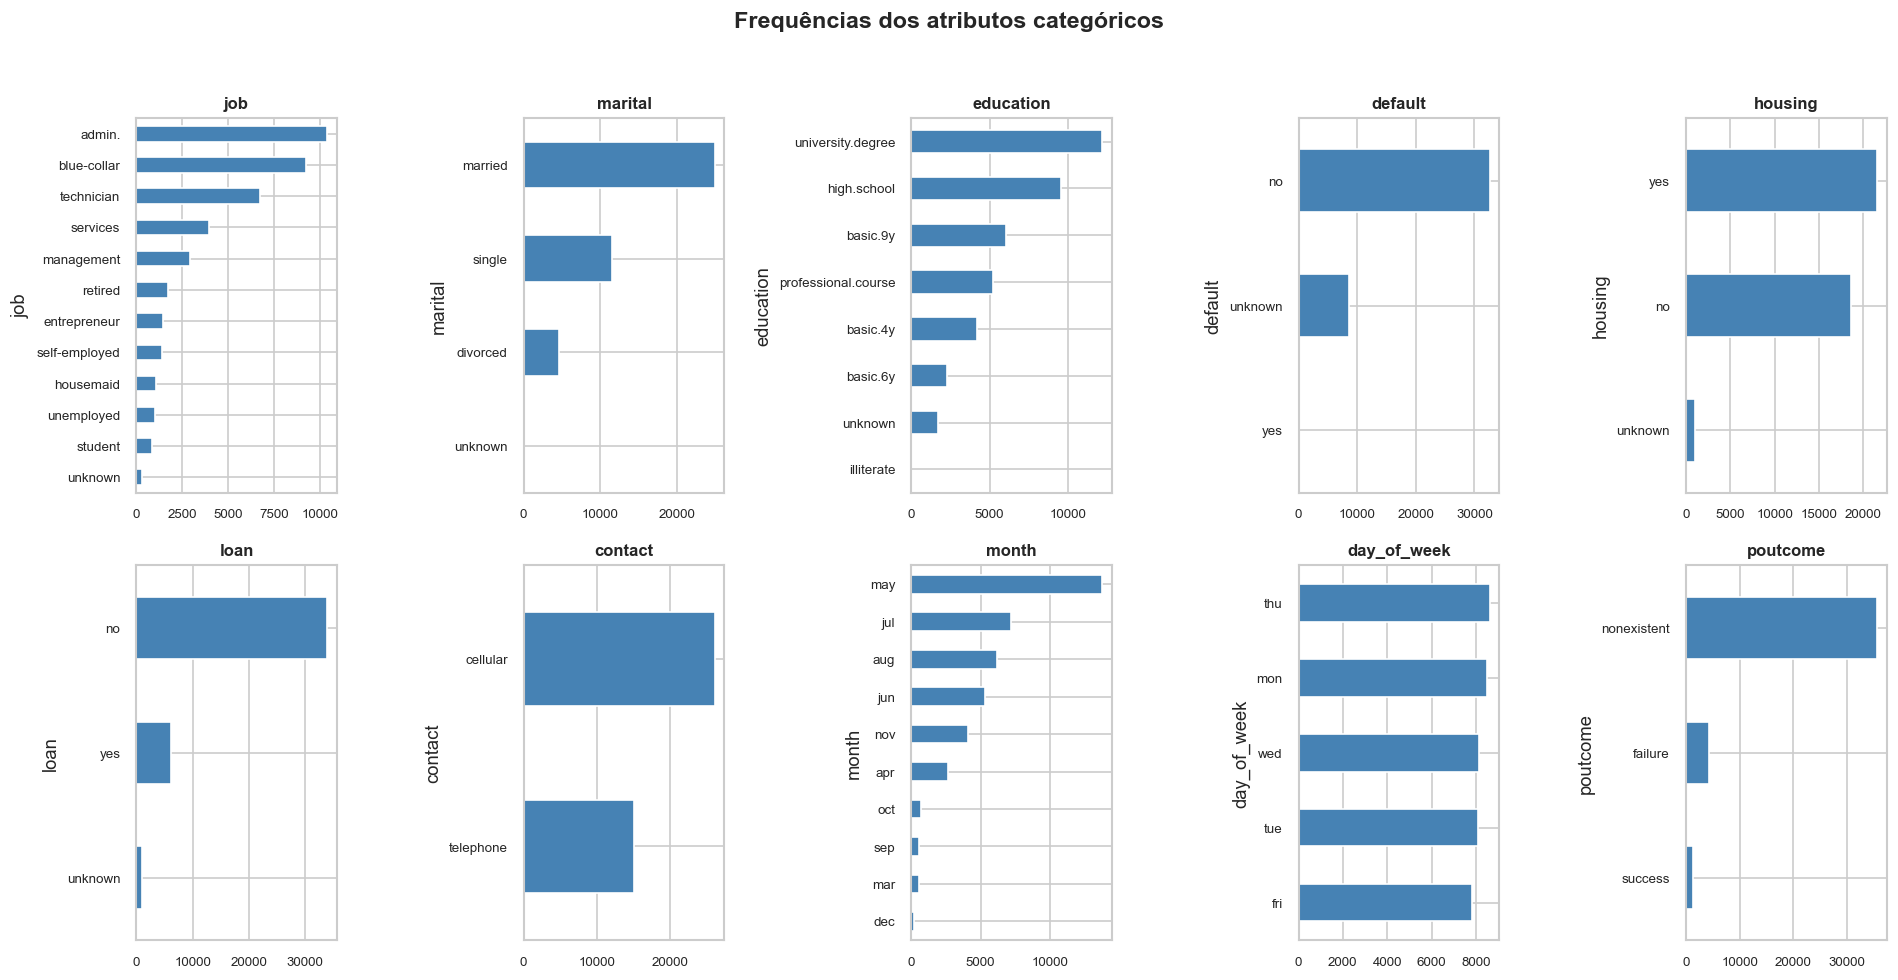

In [138]:
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle("Frequências dos atributos categóricos", fontsize=14, fontweight="bold", y=1.02)

for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.tick_params(labelsize=8)
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig("figures/dist_categoricos.png", dpi=150, bbox_inches="tight")
plt.show()

Observações a registrar:
- `job`: admin. e blue-collar dominam (~25% e ~22%); student e unknown são categorias raras (<3%)
- `marital`: casados compõem a maioria (~61%); "unknown" é desprezível
- `education`: university.degree e high.school lideram; illiterate é praticamente inexistente (poucos casos podem causar instabilidade em splits de CV)
- `default`: esmagadoramente "no" (~79%), porém "unknown" é o segundo maior grupo (~20%), enquanto "yes" é raríssimo (~1.8%). \
$\uparrow$ Hipótese: "unknown" pode ser proxy para inadimplência que o cliente prefere não declarar - investigar na bivariada
- `housing`: distribuição mais equilibrada entre yes (~53%) e no (~45%)
- `loan`: maioria "no" (~82%); feature com baixa entropia
- `contact`: cellular domina (~63%); reflete o período da coleta (2008-2010, crescimento dos smartphones)
- `month`: maio é disparado o mês com mais ligações - provável campanha massiva naquele mês. Dezembro e março são raros. \
$\uparrow$ Essa feature captura quando *o banco* decidiu ligar, não uma característica do cliente
- `day_of_week`: distribuição quase uniforme entre os dias úteis - pouco poder discriminativo esperado
- `poutcome`: "nonexistent" domina (~86%), alinhado com pdays=999 \
$\uparrow$ A maioria dos clientes nunca foi contactada antes. Os ~3% de "success" são um grupo pequeno mas potencialmente informativo

---

## Análise Bivariada

Agora cruzamos cada feature com a target (`y`). O objetivo é identificar quais \
variáveis *separam* os clientes que subscreveram dos que não subscreveram.

Testes aplicados:
- Variáveis Numéricas: Mann-Whitney U (não-paramétrico, pois as distribuições não são normais) \
    Tamanho de efeito: correlação rank-biserial ($r$), onde $|r| > 0.3$ indica efeito médio e $|r| > 0.5$ efeito grande

- Variáveis Categóricas: Chi-quadrado de independência \
    Tamanho de efeito: $V$ de Cramér, onde $V > 0.1$ é pequeno, $> 0.3$ médio, $> 0.5$ grande

### Para as contínuas - violinplots + Mann-Whitney

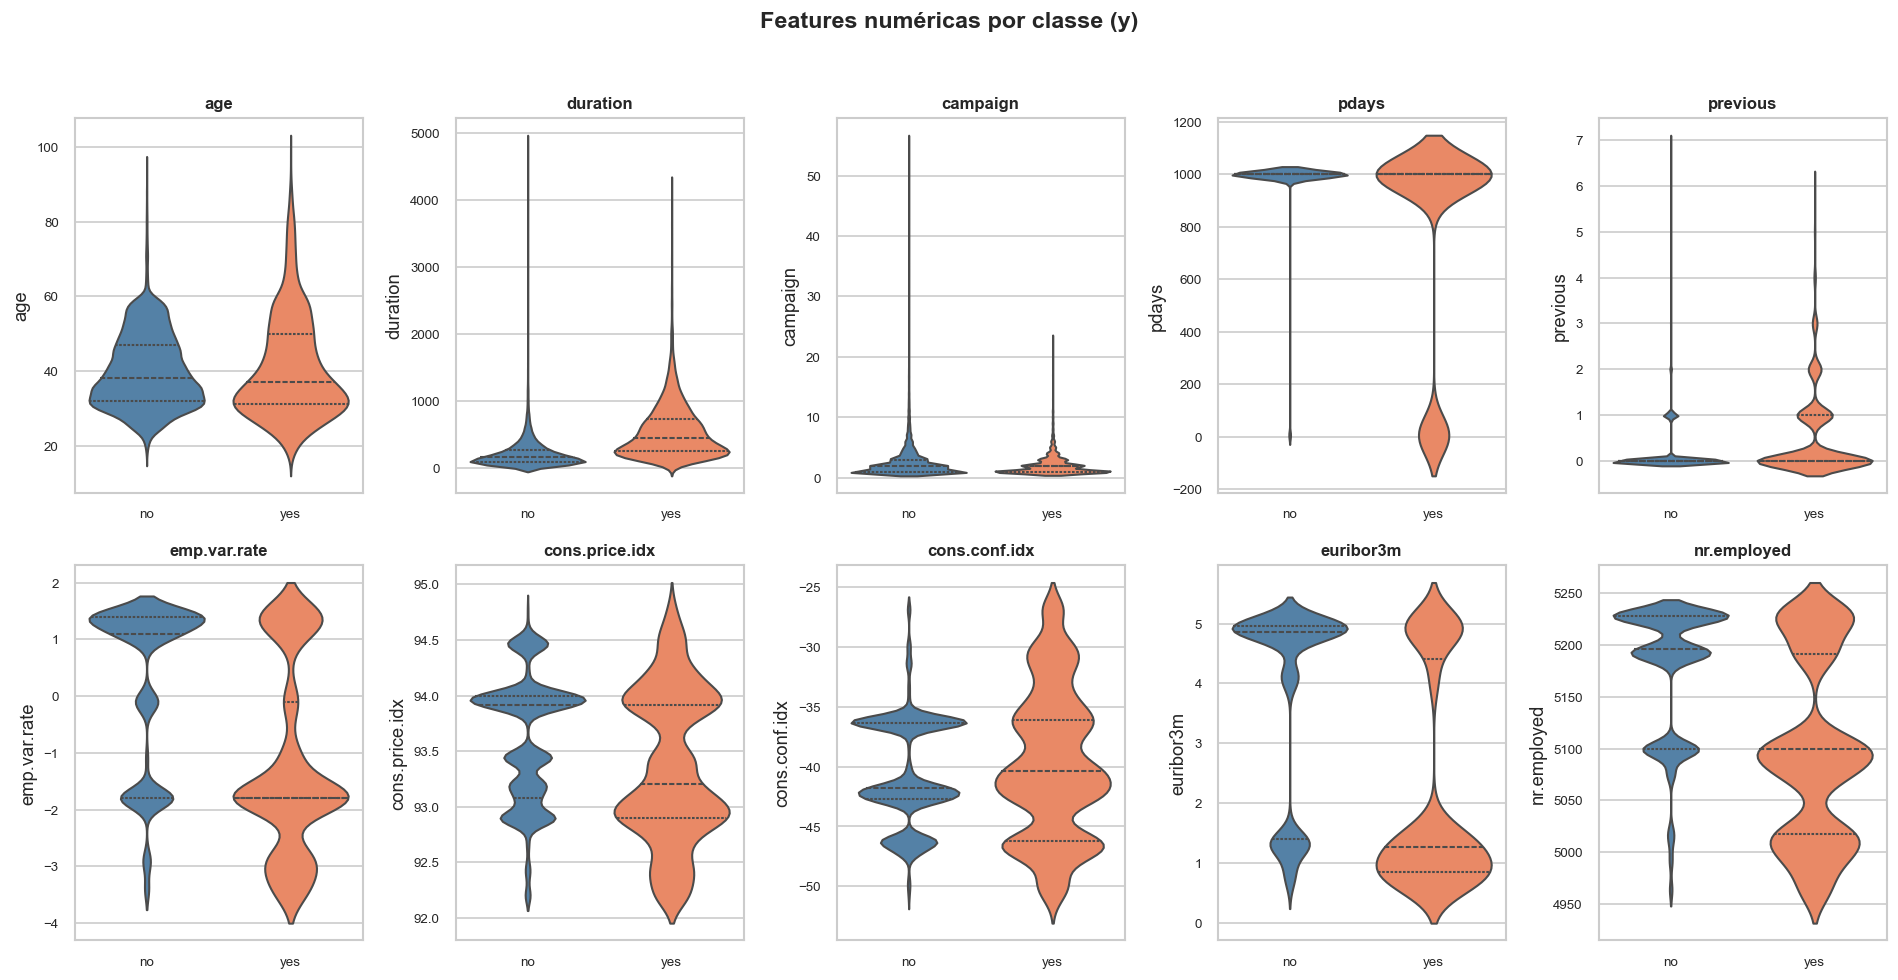

In [139]:
# --- violinplots por classe ---
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle("Features numéricas por classe (y)", fontsize=14, fontweight="bold", y=1.02)

for ax, col in zip(axes.flat, num_cols):
    sns.violinplot(
        data=df, x="y", y=col, hue="y",
        palette={"no": "steelblue", "yes": "coral"},
        inner="quartile", ax=ax, legend=False, density_norm="width"
    )
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(labelsize=8)

plt.tight_layout()
fig.savefig("figures/violin_numericos.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
# --- tabela de testes Mann-Whitney U ---
yes_mask = df["y"] == "yes"
mw_rows = []

for col in num_cols:
    g_yes = df.loc[yes_mask, col]
    g_no  = df.loc[~yes_mask, col]
    u_stat, p_val = stats.mannwhitneyu(g_yes, g_no, alternative="two-sided")
    n1, n2 = len(g_yes), len(g_no)
    rank_biserial = 1 - (2 * u_stat) / (n1 * n2)
    mw_rows.append({
        "feature": col,
        "median_yes": g_yes.median(),
        "median_no": g_no.median(),
        "U": u_stat,
        "p_value": p_val,
        "rank_biserial_r": rank_biserial,
        "|r|": abs(rank_biserial),
    })

mw_df = pd.DataFrame(mw_rows).sort_values("|r|", ascending=False).reset_index()

,index,feature,median_yes,median_no,U,p_value,rank_biserial_r,|r|
0,1,duration,449.0000,163.5000,138794276.5000,0.0000,-0.6369,0.6369
1,9,nr.employed,5099.1001,5195.7998,42565804.0000,0.0000,0.4980,0.4980
2,8,euribor3m,1.2660,4.8570,43501744.0000,0.0000,0.4870,0.4870
3,5,emp.var.rate,-1.8000,1.1000,48033800.0000,0.0000,0.4335,0.4335
4,6,cons.price.idx,93.2000,93.9180,66041976.0000,0.0000,0.2211,0.2211
5,4,previous,0.0000,0.0000,103324818.5000,0.0000,-0.2186,0.2186
6,3,pdays,999.0000,999.0000,68384810.0000,0.0000,0.1935,0.1935
7,2,campaign,2.0000,2.0000,75428808.5000,0.0000,0.1104,0.1104
8,7,cons.conf.idx,-40.4000,-41.8000,91117808.0000,0.0000,-0.0746,0.0746
9,0,age,37.0000,38.0000,82955833.5000,0.0161,0.0216,0.0216


Rank-biserial $r$ - tamanho de efeito para Mann-Whitney U:

$$r = 1 - \frac{2U}{n_1 \cdot n_2}$$

Interpretação: é a diferença entre a probabilidade de um valor aleatório do grupo *yes* superar um do \
grupo *no* e o inverso, normalizada em $[-1, +1]$. Por exemplo: $r = -0.49$ para `nr.employed` indica que, ao \
sortear um cliente que subscreveu e um que não subscreveu, há ~75% de chance de o assinante estar associado \
a um valor *menor* de empregados.

| $|r|$ | Magnitude |
|---|---|
| $< 0.1$ | Desprezível |
| $0.1 - 0.3$ | Pequena |
| $0.3 - 0.5$ | Média |
| $> 0.5$ | Grande |

Destaques da tabela:
    
* `duration` ($|r| = 0.64$, grande, porém *leakage*)
* `nr.employed` ($0.50$), `euribor3m` ($0.49$) e `emp.var.rate` ($0.43$)
* `age` ($0.02$) e `cons.conf.idx` ($0.07$) têm poder discriminativo desprezível

### Para as discretas - proporções + Chi-quadrado

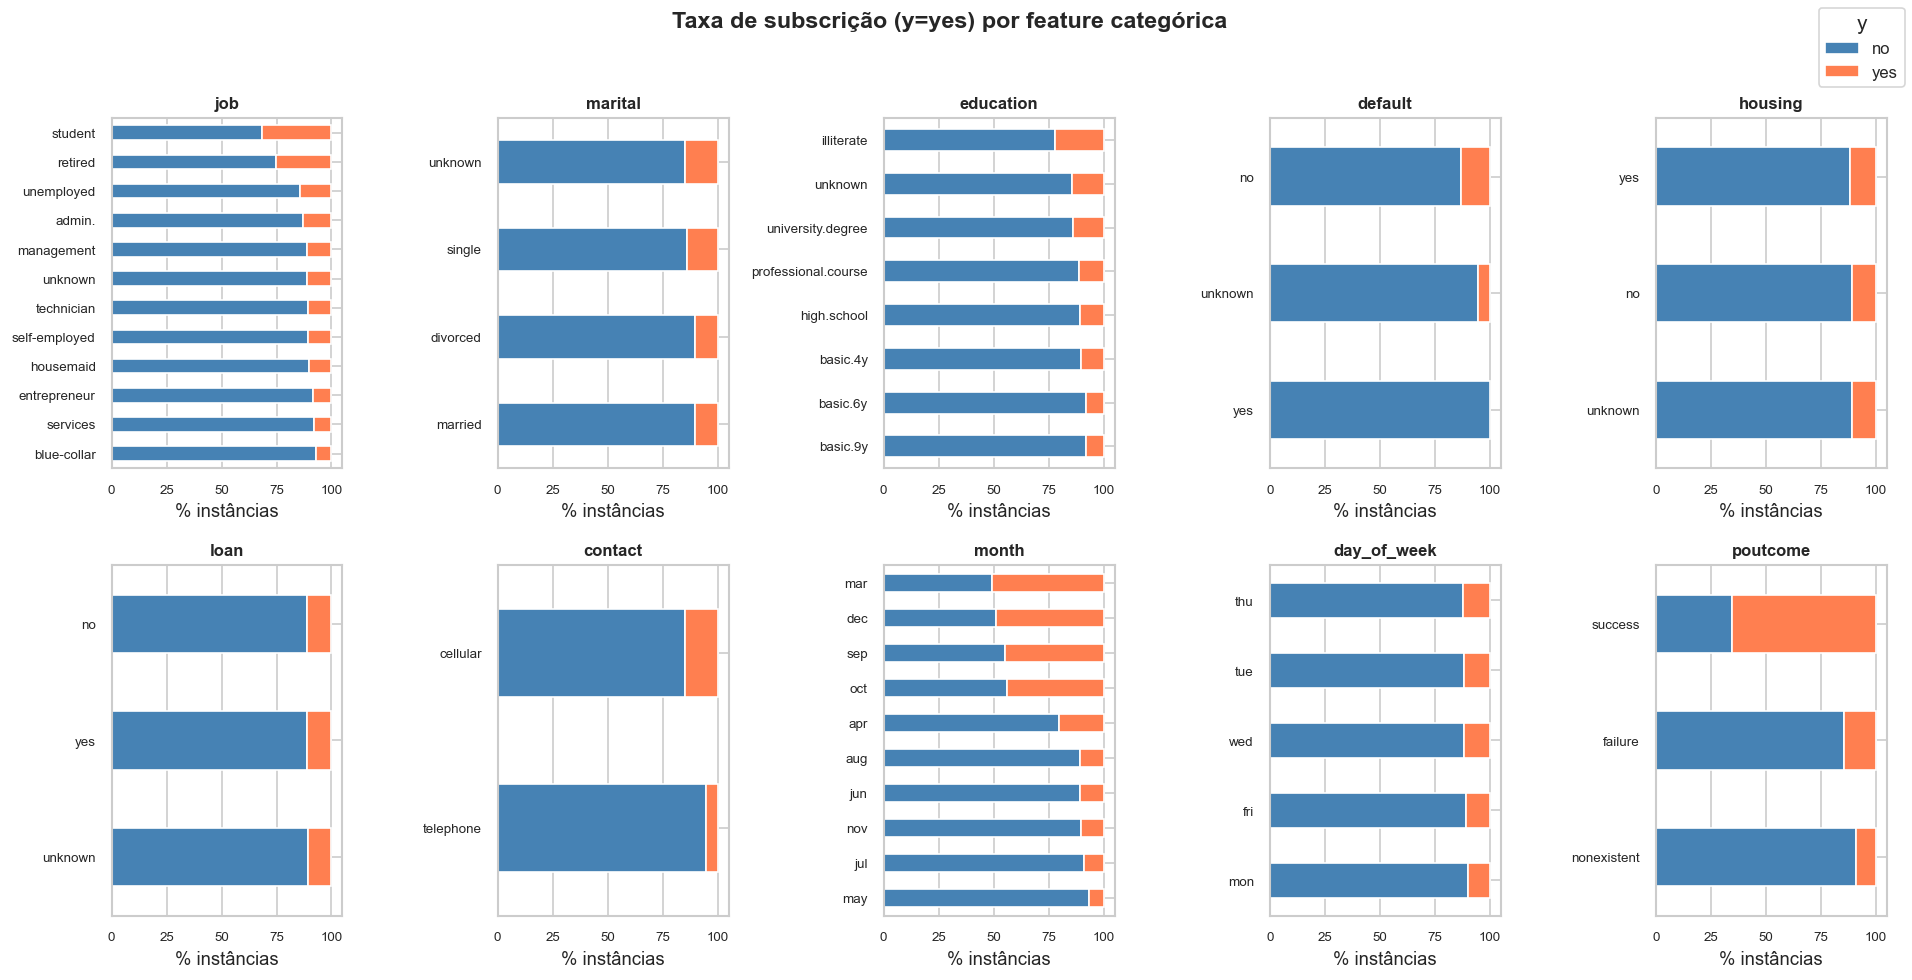

In [140]:
# --- taxa de conversão por categoria ---
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle("Taxa de subscrição (y=yes) por feature categórica", fontsize=14, fontweight="bold", y=1.02)

for ax, col in zip(axes.flat, cat_cols):
    ct = pd.crosstab(df[col], df["y"], normalize="index") * 100
    ct = ct.sort_values("yes", ascending=True)
    ct.plot.barh(stacked=True, ax=ax, color=["steelblue", "coral"], edgecolor="white", legend=False)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("% instâncias")
    ax.set_ylabel("")
    ax.tick_params(labelsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, ["no", "yes"], loc="upper right", fontsize=10, title="y")
plt.tight_layout()
fig.savefig("figures/crosstab_categoricos.png", dpi=150, bbox_inches="tight")
plt.show()

In [39]:
# --- tabela de testes Chi-quadrado ---
chi2_rows = []

for col in cat_cols:
    ct = pd.crosstab(df[col], df["y"])
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    n = ct.values.sum()
    k = min(ct.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * k)) if k > 0 else 0.0
    chi2_rows.append({
        "feature": col,
        "chi2": chi2,
        "dof": dof,
        "p_value": p_val,
        "cramers_v": cramers_v,
    })

chi2_df = pd.DataFrame(chi2_rows).sort_values("cramers_v", ascending=False)

,feature,chi2,dof,p_value,cramers_v
9,poutcome,4230.5238,2,0.0000,0.3205
7,month,3101.1494,9,0.0000,0.2744
0,job,961.2424,11,0.0000,0.1528
6,contact,862.3184,1,0.0000,0.1447
3,default,406.5775,2,0.0000,0.0994
2,education,193.1059,7,0.0000,0.0685
1,marital,122.6552,3,0.0000,0.0546
8,day_of_week,26.1449,4,0.0000,0.0252
4,housing,5.6845,2,0.0583,0.0117
5,loan,1.0940,2,0.5787,0.0052


$V$ de Cramér - tamanho de efeito para Chi-quadrado:

$$V = \sqrt{\frac{\chi^2}{n \cdot (k - 1)}}, \quad k = \min(\text{linhas}, \text{colunas})$$

Normaliza o $\chi^2$ removendo a influência do tamanho amostral $n$ \
e da dimensão da tabela, isolando a força pura da associação em $[0, 1]$.

| $V$ | Magnitude |
|---|---|
| $< 0.1$ | Desprezível |
| $0.1 - 0.3$ | Pequena |
| $0.3 - 0.5$ | Média |
| $> 0.5$ | Grande |

Destaques desta tabela:
* `poutcome` ($V = 0.32$, média) é a mais discriminativa - clientes com sucesso prévio têm ~65% de taxa de subscrição
* `month` ($V = 0.27$) captura efeito temporal de campanhas - houve principalmente uma campanha no mês de maio

> Nota: `housing` ($p = 0.058$) e `loan` ($p = 0.578$) **não** são significativas mesmo com $n = 41\text{K}$ - efeito genuinamente nulo.

---

### Correlação entre numéricas - Spearman

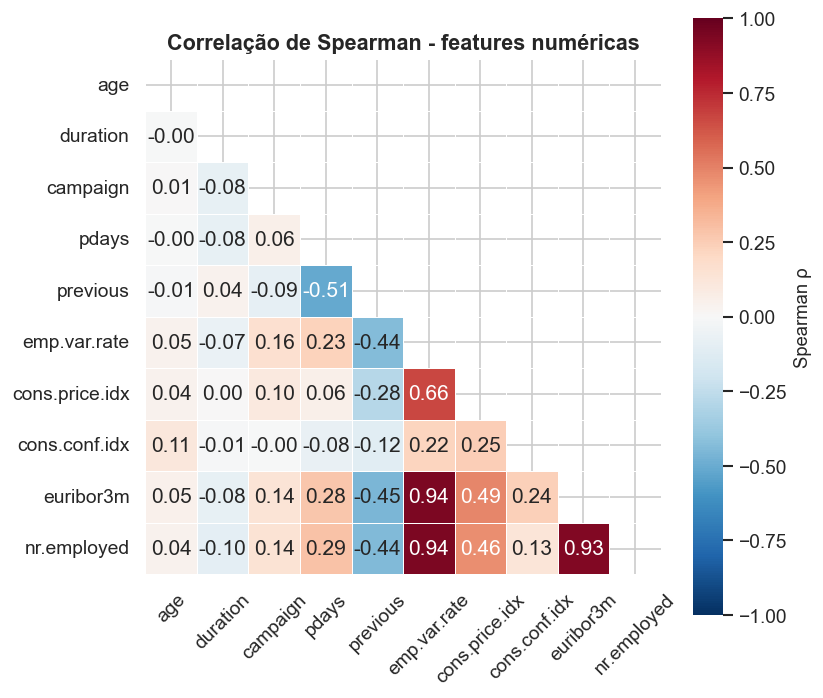

In [141]:
corr = df[num_cols].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Spearman ρ"}
)
ax.set_title("Correlação de Spearman - features numéricas", fontsize=13, fontweight="bold")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
fig.savefig("figures/corr_spearman_numericos.png", dpi=150, bbox_inches="tight")
plt.show()

Correlação de Spearman $\rho$:

$$\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}, \quad d_i = \text{rank}(x_i) - \text{rank}(y_i)$$

Mede relação *monotônica* (não necessariamente linear). Preferimos Spearman a Pearson aqui por três razões:
1. As distribuições são não-normais
2. Spearman é robusto a outliers (opera sobre ranks)
3. Captura relações monotônicas não-lineares que Pearson ignoraria

**Multicolinearidade severa no bloco socioeconômico:**
- `emp.var.rate` $\leftrightarrow$ `euribor3m`: $\rho = 0.94$
- `emp.var.rate` $\leftrightarrow$ `nr.employed`: $\rho = 0.94$
- `euribor3m` $\leftrightarrow$ `nr.employed`: $\rho = 0.93$

Essas três features são proxies de um mesmo sinal macroeconômico. Manter todas introduz multicolinearidade, \
que infla a variância dos coeficientes em modelos lineares (logística, SVM). A etapa de *feature selection* \
deverá reter no máximo uma - ou usar PCA para comprimi-las.

Fora do bloco: `pdays` $\leftrightarrow$ `previous` ($\rho = -0.51$) reflete que clientes contactados mais vezes foram contactados mais recentemente.

---

## Sumário da EDA

1. Desbalanceamento: ~88/12 - usar stratified splits, métricas F1 e ROC-AUC em vez de acurácia
2. `duration`: maior poder discriminativo ($|r| = 0.64$), porém constitui *data leakage* - treinaremos modelos com e sem ela para quantificar o impacto
3. `pdays`: 96% dos valores são 999 - criaremos feature binária `was_contacted` e descartaremos a original
4. Multicolinearidade socioeconômica: `euribor3m`, `emp.var.rate` e `nr.employed` ($\rho > 0.93$ entre si) - feature selection pra reter no máximo uma ou comprimir via PCA
5. Assimetria: `campaign` e `previous` possuem cauda longa à direita ($\gamma_1 > 1$)
6. Features categóricas mais discriminativas: `poutcome` ($V = 0.32$) e `month` ($V = 0.27$); menos: `housing` e `loan` são estatisticamente irrelevantes ($p > 0.05$)
7. Features numéricas mais discriminativas (excl. `duration`):** `nr.employed` ($|r| = 0.50$), `euribor3m` ($|r| = 0.49$), `emp.var.rate` ($|r| = 0.43$)
8. Features com poder desprezível: `age` ($|r| = 0.02$), `cons.conf.idx` ($|r| = 0.07$), `day_of_week` ($V = 0.03$), `loan` ($V = 0.005$)

---

Roadmap:
1. ✅ Carregamento e otimização de memória
2. ✅ EDA (univariada + bivariada + correlações + sumário)
3. Pré-processamento + Feature Engineering + Split
4. Feature Selection (somente no treino)
5. Modelagem + Cross-Validation
6. Tuning de hiperparâmetros (validação)
7. Avaliação final (teste) + comparação estatística (McNemar)

---

# Pré-processamento, Feature Engineering e Splits

Antes de qualquer transformação, dividimos os dados em treino/validação/teste para evitar *data leakage*. \
O pré-processamento (scaling, encoding) é **ajustado apenas no treino** e aplicado igualmente nos outros conjuntos.

Estratégia de split: 70% treino / 15% validação / 15% teste, com estratificação pelo target para preservar a proporção 88/12 em cada partição.

Feature engineering:
- `pdays` → feature binária `was_contacted` (1 se contactado, 0 caso contrário)
- `duration` mantida para análise comparativa, com flag para exclusão no cenário sem leakage

## _Feature Engineering_ e Split

In [55]:
# --- feature engineering ---
df_model = df.copy()
df_model["was_contacted"] = (df_model["pdays"] != 999).astype(np.int8)
df_model = df_model.drop("pdays", axis=1)
df_model["y"] = df_model["y"].map({"no": 0, "yes": 1}).astype(np.int8)

# --- grupos de features ---
num_features = [
    "age", "duration", "campaign", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]
cat_features = [
    "job", "marital", "education", "default", "housing",
    "loan", "contact", "month", "day_of_week", "poutcome"
]
bin_features = ["was_contacted"]

['was_contacted']

In [56]:
# --- split estratificado 70/15/15 ---
X = df_model[num_features + cat_features + bin_features]
y = df_model["y"]

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=SEED # 42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=round(0.15 / 0.85, 4),   # ~0.1765 → 15% do total
    stratify=y_temp, random_state=SEED
)

In [69]:
for name, xs, ys in [("Treino", X_train, y_train),
                      ("Validação", X_val, y_val),
                      ("Teste", X_test, y_test)]:
    print(f"{name:>10}: {xs.shape[0]:>5} amostras | {ys.sum():>5} positivos ({ys.mean():.2%}) | {len(ys) - ys.sum():>5} neg")

    Treino: 28829 amostras |  3248 positivos (11.27%) | 25581 neg
 Validação:  6180 amostras |   696 positivos (11.26%) |  5484 neg
     Teste:  6179 amostras |   696 positivos (11.26%) |  5483 neg


---

## Pipeline de pré-processamento

In [70]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(
            drop="first",           # evita dummy trap (multicolinearidade em modelos lineares)
            sparse_output=False,
            handle_unknown="ignore" # segurança caso val/test tenham categorias ausentes
        ), cat_features),
        ("bin", "passthrough", bin_features),
    ]
)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [71]:
# fit APENAS no treino
preprocessor.fit(X_train)

X_train_enc = preprocessor.transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test);

In [75]:
# recuperar nomes das features
ohe_names = preprocessor.named_transformers_["cat"] \
    .get_feature_names_out(cat_features).tolist()
all_feature_names = num_features + ohe_names + bin_features

['age',
 'duration',
 'campaign',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'marital_unknown',
 'education_basic.6y',
 'education_basic.9y',
 'education_high.school',
 'education_illiterate',
 'education_professional.course',
 'education_university.degree',
 'education_unknown',
 'default_unknown',
 'default_yes',
 'housing_unknown',
 'housing_yes',
 'loan_unknown',
 'loan_yes',
 'contact_telephone',
 'month_aug',
 'month_dec',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'day_of_week_mon',
 'day_of_week_thu',
 'day_of_week_tue',
 'day_of_week_wed',
 'poutcome_nonexistent',
 'poutcome_success',
 'was_contacted']

In [76]:
# converter para DataFrame pra inspeção
X_train_enc = pd.DataFrame(X_train_enc, columns=all_feature_names, index=X_train.index)
X_val_enc   = pd.DataFrame(X_val_enc,   columns=all_feature_names, index=X_val.index)
X_test_enc  = pd.DataFrame(X_test_enc,  columns=all_feature_names, index=X_test.index);

In [81]:
# features sem leakage (excluindo duration)
no_leak_cols = [c for c in all_feature_names if c != "duration"]

['age',
 'campaign',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed',
 'job_blue-collar',
 'job_entrepreneur',
 'job_housemaid',
 'job_management',
 'job_retired',
 'job_self-employed',
 'job_services',
 'job_student',
 'job_technician',
 'job_unemployed',
 'job_unknown',
 'marital_married',
 'marital_single',
 'marital_unknown',
 'education_basic.6y',
 'education_basic.9y',
 'education_high.school',
 'education_illiterate',
 'education_professional.course',
 'education_university.degree',
 'education_unknown',
 'default_unknown',
 'default_yes',
 'housing_unknown',
 'housing_yes',
 'loan_unknown',
 'loan_yes',
 'contact_telephone',
 'month_aug',
 'month_dec',
 'month_jul',
 'month_jun',
 'month_mar',
 'month_may',
 'month_nov',
 'month_oct',
 'month_sep',
 'day_of_week_mon',
 'day_of_week_thu',
 'day_of_week_tue',
 'day_of_week_wed',
 'poutcome_nonexistent',
 'poutcome_success',
 'was_contacted']

In [82]:
print(f"Features após encoding: {X_train_enc.shape[1]} (com duration)")
print(f"Features sem leakage:   {len(no_leak_cols)}")
X_train_enc

Features após encoding: 53 (com duration)
Features sem leakage:   52


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success,was_contacted
5567,0.3828,-0.6225,-0.2021,-0.3505,0.6493,0.7233,0.8890,0.7139,0.3326,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
4415,0.2869,1.0964,1.6283,-0.3505,0.6493,0.7233,0.8890,0.7133,0.3326,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
41002,0.4786,0.2160,-0.2021,3.6661,-0.7501,1.7716,-1.9422,-1.4988,-2.8097,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
32783,-0.6716,-0.9083,1.2622,-0.3505,-1.1953,-1.1782,-1.2290,-1.3357,-0.9373,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000
21797,-0.7674,-0.7788,-0.5682,-0.3505,0.8401,-0.2266,0.9538,0.7755,0.8452,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36363,-0.8633,-0.5958,-0.5682,3.6661,-1.8950,-1.0573,-0.0620,-1.3571,-1.2538,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000
37339,1.1496,0.5666,-0.5682,-0.3505,-1.8950,-2.3733,1.9696,-1.5754,-1.2538,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000
32185,-0.7674,-0.4777,-0.5682,1.6578,-1.1953,-1.1782,-1.2290,-1.3277,-0.9373,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,

## Formato pós-processado

In [104]:
print(f"""
Features antes:  {X_train.shape[1]}
Features depois: {X_train_enc.shape[1]}
""")


Features antes:  20
Features depois: 53



In [107]:
print(f"""
Amostras treino:    {X_train_enc.shape[0]:,}
Amostras validação: {X_val_enc.shape[0]:,}
Amostras teste:     {X_test_enc.shape[0]:,}
""")


Amostras treino:    28,829
Amostras validação: 6,180
Amostras teste:     6,179



---

# _Feature Selection_

Aplicamos três métodos complementares **apenas nos dados de treino**, depois selecionamos por consenso:

1. Mutual Information: mede a dependência entre cada feature e o target sem assumir linearidade. Baseado em teoria da informação - captura qualquer tipo de relação.
2. Random Forest: mede quanto cada feature contribui para redução de impureza (Gini) nas árvores. Captura interações não-lineares.
3. LASSO / Regressão Logística com L1: penaliza coeficientes, forçando os irrelevantes a zero. \
$\uparrow$ Requer features na mesma escala (já temos via `StandardScaler`). Captura relações aproximadamente lineares.

A seleção final retém features que aparecem consistentemente bem ranqueadas em pelo menos dois dos três métodos.

## Mutual Information

In [93]:
mi_scores = mutual_info_classif(
    X_train_enc[no_leak_cols],
    y_train,
    n_neighbors=5,
    random_state=SEED
)
mi_df = pd.DataFrame({
    "feature": no_leak_cols,
    "MI": mi_scores
}).sort_values("MI", ascending=False).reset_index(drop=True)
mi_df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
feature,euribor3m,cons.price.idx,cons.conf.idx,nr.employed,emp.var.rate,was_contacted,poutcome_success,previous,poutcome_nonexistent,age,contact_telephone,default_unknown,month_sep,job_student,month_oct,month_may,month_mar,campaign,job_retired,marital_married,month_dec,job_blue-collar,day_of_week_tue,marital_single,education_university.degree,job_entrepreneur,education_professional.course,education_basic.9y,job_services,housing_yes,month_aug,education_illiterate,loan_yes,education_unknown,education_basic.6y,job_housemaid,default_yes,loan_unknown,job_unemployed,day_of_week_wed,job_unknown,job_technician,job_self-employed,job_management,housing_unknown,education_high.school,marital_unknown,month_jul,month_nov,month_jun,day_of_week_thu,day_of_week_mon
MI,0.0747,0.0687,0.0663,0.0611,0.0546,0.0310,0.0309,0.0206,0.0171,0.0126,0.0113,0.0081,0.0068,0.0066,0.0061,0.0060,0.0055,0.0047,0.0039,0.0038,0.0037,0.0036,0.0036,0.0035,0.0031,0.0021,0.0019,0.0018,0.0017,0.0015,0.0014,0.0010,0.0010,0.0009,0.0007,0.0006,0.0004,0.0004,0.0004,0.0001,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


Mutual Information (MI) - método de filtro

A MI mede a redução de incerteza (entropia) sobre o target $Y$ ao conhecer a feature $X$:

$$\text{MI}(X, Y) = H(Y) - H(Y|X) = \sum_{x,y} p(x,y) \log \frac{p(x,y)}{p(x)\,p(y)}$$

A Entropia $H(Y)$ mede a incerteza sobre $Y$. Se você soubesse o valor de X antes, \
a incerteza restante seria $H(Y|X)$. A diferença MI(X,Y) = H(Y) - H(Y|X) é quanta \
incerteza sobre $Y$ a feature $X$ elimina. Se $MI \approx 0$, saber X não te ensina \
nada sobre $Y$ - feature inútil. Se MI é alta, $X$ carrega informação sobre $Y$ - feature boa.

> Nota: pra features contínuas, o `sklearn` usa um estimador baseado em KNN [(Kraskov et al., 2004)](https://arxiv.org/pdf/2410.10082).

Diferente de correlação, a MI captura dependências **não-lineares e não-monotônicas**.

| MI | Interpretação |
|---|---|
| $\approx 0$ | Feature independente do target (descartar) |
| $> 0.01$ | Alguma dependência |
| $> 0.05$ | Dependência relevante |

`euribor3m` ($0.075$) é o que mais reduz incerteza sobre y. Tudo abaixo de ~0.01 está no ruído. \
As features `day_of_week_*` e vários `job_*` têm $MI \approx 0$ - saber o dia da semana ou se o cliente \
é técnico não ajuda a prever subscrição.

---

## Random Forest Importance

In [94]:
rf_selector = RandomForestClassifier(
    n_estimators=300, max_depth=15,
    random_state=SEED, n_jobs=-1
)
rf_selector.fit(X_train_enc[no_leak_cols], y_train)

rf_imp = pd.DataFrame({
    "feature": no_leak_cols,
    "importance": rf_selector.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)
rf_imp.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
feature,euribor3m,age,nr.employed,poutcome_success,campaign,was_contacted,cons.conf.idx,cons.price.idx,emp.var.rate,previous,housing_yes,contact_telephone,loan_yes,marital_married,education_university.degree,day_of_week_mon,marital_single,day_of_week_thu,day_of_week_tue,poutcome_nonexistent,education_high.school,job_technician,day_of_week_wed,education_professional.course,month_oct,job_blue-collar,month_may,default_unknown,job_retired,education_basic.9y,month_mar,job_management,job_services,education_unknown,job_student,job_self-employed,education_basic.6y,job_unemployed,month_jun,job_housemaid,job_entrepreneur,loan_unknown,housing_unknown,month_sep,month_jul,month_aug,month_nov,job_unknown,month_dec,marital_unknown,education_illiterate,default_yes
importance,0.1659,0.0975,0.0894,0.0548,0.0490,0.0484,0.0483,0.0398,0.0379,0.0247,0.0210,0.0195,0.0154,0.0146,0.0143,0.0142,0.0135,0.0134,0.0132,0.0131,0.0124,0.0123,0.0119,0.0103,0.0093,0.0092,0.0091,0.0089,0.0088,0.0087,0.0085,0.0078,0.0069,0.0069,0.0063,0.0058,0.0050,0.0049,0.0044,0.0041,0.0041,0.0040,0.0040,0.0039,0.0035,0.0032,0.0028,0.0024,0.0015,0.0010,0.0005,0.0000


Random Forest Importance - método embedded

A importância Gini (MDI - *Mean Decrease Impurity*) soma, pra cada feature, a redução \
ponderada de impureza Gini em todos os nós que a utilizam, através de todas as árvores:

$$\text{Imp}(x_j) = \frac{1}{T} \sum_{t=1}^{T} \sum_{v \in \text{nós de } t \text{ usando } x_j} \frac{n_v}{n} \left( \text{Gini}_{v} - \text{Gini}_{esq} - \text{Gini}_{dir} \right)$$

As importâncias somam 1.0. **Viés conhecido:** features contínuas com muitos valores \
únicos (ex.: `age` com 78) são favorecidas pois oferecem mais pontos de corte, inflando\
sua importância relativa a features binárias.

| Importância | Interpretação |
|---|---|
| $> 0.05$ | Feature relevante |
| $0.01 - 0.05$ | Contribuição moderada |
| $< 0.01$ | Contribuição marginal |

---

## LASSO (Logística com L1)

In [91]:
lr_l1 = LogisticRegression(
    l1_ratio=1,
    solver="saga", C=1.0, max_iter=5000,
    random_state=SEED
)
lr_l1.fit(X_train_enc[no_leak_cols], y_train)

lasso_imp = pd.DataFrame({
    "feature": no_leak_cols,
    "abs_coef": np.abs(lr_l1.coef_[0])
}).sort_values("abs_coef", ascending=False).reset_index(drop=True)

n_zeroed = (lasso_imp["abs_coef"] == 0).sum()
print(f"Features eliminadas pelo L1 (coef = 0): {n_zeroed} / {len(no_leak_cols)}")
lasso_imp.T

Features eliminadas pelo L1 (coef = 0): 2 / 52


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51
feature,emp.var.rate,month_mar,was_contacted,cons.price.idx,poutcome_success,contact_telephone,month_jun,month_nov,education_illiterate,month_may,poutcome_nonexistent,month_aug,nr.employed,euribor3m,job_retired,month_dec,default_unknown,day_of_week_mon,marital_unknown,job_unknown,day_of_week_wed,job_blue-collar,job_housemaid,job_services,cons.conf.idx,education_university.degree,education_basic.9y,job_student,month_sep,job_self-employed,campaign,marital_single,day_of_week_tue,month_jul,education_unknown,education_basic.6y,previous,day_of_week_thu,month_oct,job_entrepreneur,marital_married,education_professional.course,housing_unknown,loan_unknown,job_management,job_technician,job_unemployed,age,loan_yes,housing_yes,default_yes,education_high.school
abs_coef,2.0291,1.3248,1.1536,1.0554,0.7178,0.7124,0.6163,0.5316,0.4829,0.4570,0.3568,0.3472,0.3284,0.2994,0.2722,0.2520,0.2472,0.1901,0.1786,0.1687,0.1617,0.1550,0.1516,0.1378,0.1324,0.1163,0.1104,0.1052,0.1013,0.0987,0.0986,0.0845,0.0840,0.0790,0.0753,0.0706,0.0611,0.0468,0.0454,0.0406,0.0339,0.0324,0.0248,0.0248,0.0237,0.0199,0.0165,0.0033,0.0028,0.0019,0.0000,0.0000


Lasso (Regressão Logística com L1) - método embedded

A penalização L1 adiciona a soma dos valores absolutos dos coeficientes à função de perda:

$$\mathcal{L} = -\text{log-likelihood} + \frac{1}{C} \sum_{j=1}^{p} |\beta_j|$$

Geometricamente, a "bola" L1 tem vértices sobre os eixos, forçando coeficientes pequenos \
a **exatamente zero** - resultando em eliminação automática de features. O parâmetro $C$ \
controla a intensidade: menor $C$ = mais regularização = mais zeros.

Com $C = 1.0$, apenas 2 features foram eliminadas (`default_yes`, `education_high.school`), \
indicando que a maioria possui algum valor preditivo linear.

Os coeficientes estão em escala padronizada (devido ao `StandardScaler`), portanto são \
diretamente *comparáveis*: $|\beta| = 2.03$ para `emp.var.rate` indica que uma mudança \
de 1 desvio padrão nessa feature altera o log-odds da subscrição em 2.03.

> Efeito da multicolinearidade no LASSO: quando features são altamente correlacionadas ($\rho > 0.9$), \
o L1 tende a selecionar só uma e suprimir as demais. É por isso que `emp.var.rate` domina ($|\beta| = 2.03$) \
enquanto `euribor3m` ($0.30$) e `nr.employed` ($0.33$) ficam com coeficientes modestos, apesar de serem \
altamente discriminativos pela MI e RF.

---

## Comparação Normalizada

In [117]:
# --- normalizar scores para [0, 1] ---
mi_norm   = mi_df.set_index("feature")["MI"] / mi_df["MI"].max()
rf_norm   = rf_imp.set_index("feature")["importance"] / rf_imp["importance"].max()
l1_norm   = lasso_imp.set_index("feature")["abs_coef"] / lasso_imp["abs_coef"].max()

ranking = pd.DataFrame({
    "Mutual Info":   mi_norm,
    "Random Forest": rf_norm,
    "Lasso (L1)":    l1_norm,
}).fillna(0)
ranking["mean_score"] = ranking.mean(axis=1)
ranking = ranking.sort_values("mean_score", ascending=False)

,Mutual Info,Random Forest,Lasso (L1),mean_score
feature,,,,
euribor3m,1.0000,1.0000,0.1476,0.7159
emp.var.rate,0.7308,0.2282,1.0000,0.6530
cons.price.idx,0.9192,0.2396,0.5201,0.5596
nr.employed,0.8185,0.5391,0.1619,0.5065
was_contacted,0.4154,0.2916,0.5686,0.4252
cons.conf.idx,0.8881,0.2912,0.0653,0.4148
poutcome_success,0.4141,0.3303,0.3537,0.3661
month_mar,0.0743,0.0514,0.6529,0.2595
age,0.1685,0.5874,0.0016,0.2525


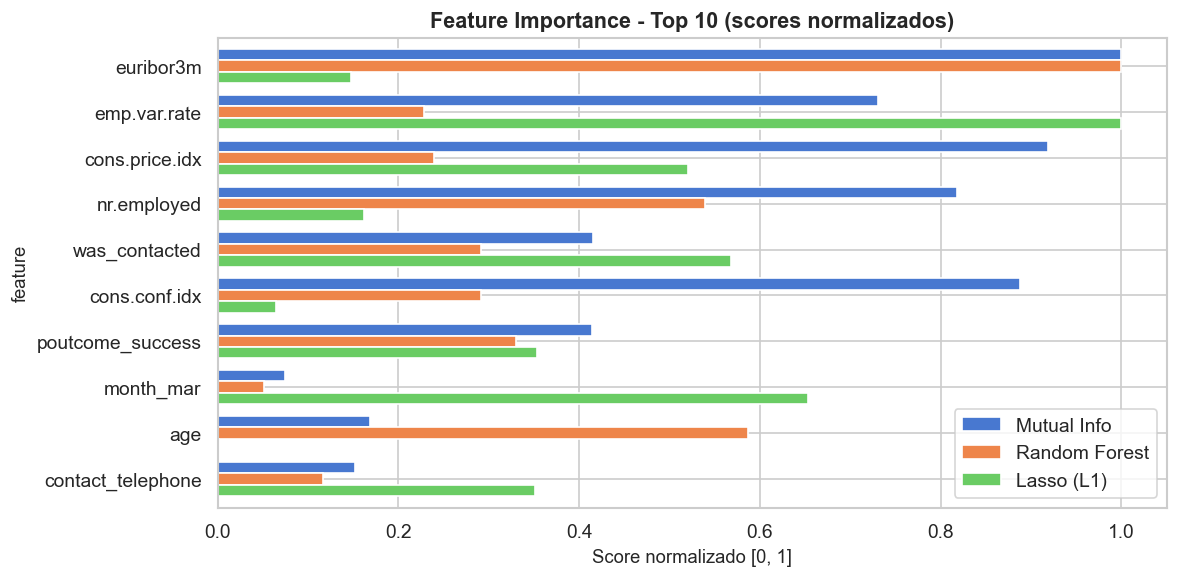

In [142]:
# --- plot top 10 ---
fig, ax = plt.subplots(figsize=(10, 5))
top10 = ranking.head(10)[["Mutual Info", "Random Forest", "Lasso (L1)"]]
top10.plot.barh(ax=ax, width=0.75)
ax.set_title("Feature Importance - Top 10 (scores normalizados)", fontweight="bold")
ax.set_xlabel("Score normalizado [0, 1]")
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
fig.savefig("figures/feature_importance_top10.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Seleção Final por Consenso

In [124]:
# consenso: top-k em pelo menos 2 dos 3 métodos
K = 10
top_mi = set(mi_df.head(K)["feature"])
top_rf = set(rf_imp.head(K)["feature"])
top_l1 = set(lasso_imp.head(K)["feature"])

consensus = sorted((top_mi & top_rf) | (top_mi & top_l1) | (top_rf & top_l1))

print(f"Features por consenso (top-{K} em pelo menos 2 dos 3 métodos): {len(consensus)}")
print(f"\n{consensus}")

# preparar datasets finais (sem leakage)
X_train_sel = X_train_enc[consensus]
X_val_sel   = X_val_enc[consensus]
X_test_sel  = X_test_enc[consensus]

print(f"\nShape treino final: {X_train_sel.shape}")

Features por consenso (top-10 em pelo menos 2 dos 3 métodos): 9

['age', 'cons.conf.idx', 'cons.price.idx', 'emp.var.rate', 'euribor3m', 'nr.employed', 'poutcome_success', 'previous', 'was_contacted']

Shape treino final: (28829, 9)


---

## Sumário da Feature Selection

1. Convergência entre métodos: `euribor3m`, `emp.var.rate`, `was_contacted`, `poutcome_success` e `contact_telephone` \
figuram no top-10 dos três métodos - são preditores robustos através das diferentes abordagens selecionadas.

2. Divergências interessantes:
    - `age` é a 2ª mais importante no RF ($0.098$) mas 48ª no Lasso ($|\beta| = 0.003$). A relação de idade-subscrição é não-linear \
    $\uparrow$ estudantes jovens e aposentados idosos subscrevem mais que a faixa intermediária) - RF captura, LASSO não
    - `month_mar` é 2ª no Lasso ($|\beta| = 1.32$) mas 17ª na MI. O mês de março tem efeito forte e linear sobre o log-odds
    - Fatores socioeconômicos dominam a MI (todo o top-5), mas o LASSO redistribui: seleciona `emp.var.rate` e suprime as demais por multicolinearidade ($\rho > 0.93$)

3. **Seleção final**: **9 features por consenso** (top-10 em pelo menos 2 dos 3 métodos), cobrindo:
    - perfil do cliente (`age`),
    - histórico de campanha (`previous`, `was_contacted`, `poutcome_success`),
    - contexto macroeconômico (`euribor3m`, `emp.var.rate`, `cons.price.idx`, `nr.employed`, `cons.conf.idx`)

---

# Salvando os Artefatos

In [125]:
import os, json, joblib

In [135]:
os.makedirs("artifacts/", exist_ok=True)
os.makedirs("figures/", exist_ok=True)

In [127]:
# --- DataFrames codificados (completos e selecionados) ---
X_train_enc.to_csv("artifacts/X_train_enc.csv")
X_val_enc.to_csv("artifacts/X_val_enc.csv")
X_test_enc.to_csv("artifacts/X_test_enc.csv")

X_train_sel.to_csv("artifacts/X_train_sel.csv")
X_val_sel.to_csv("artifacts/X_val_sel.csv")
X_test_sel.to_csv("artifacts/X_test_sel.csv")

y_train.to_csv("artifacts/y_train.csv", header=True)
y_val.to_csv("artifacts/y_val.csv", header=True)
y_test.to_csv("artifacts/y_test.csv", header=True)

In [128]:
# --- resultados de feature selection ---
mi_df.to_csv("artifacts/mi_scores.csv", index=False)
rf_imp.to_csv("artifacts/rf_importance.csv", index=False)
lasso_imp.to_csv("artifacts/lasso_importance.csv", index=False)
ranking.to_csv("artifacts/feature_ranking.csv")

In [129]:
# --- metadados ---
metadata = {
    "num_features": num_features,
    "cat_features": cat_features,
    "bin_features": bin_features,
    "no_leak_cols": no_leak_cols,
    "selected_features": consensus,
    "all_feature_names": all_feature_names,
    "SEED": SEED,
}
with open("artifacts/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

In [130]:
# --- preprocessor (scaler + encoder) ---
joblib.dump(preprocessor, "artifacts/preprocessor.joblib")

['artifacts/preprocessor.joblib']

In [134]:
files = [
    f for f in os.listdir("artifacts")
    if f != ".ipynb_checkpoints"
]

for f in sorted(files, key=lambda f: os.path.getsize(os.path.join("artifacts", f))):
    size = os.path.getsize(os.path.join("artifacts", f)) / 1024
    print(f"  {f:<35} {size:>8.1f} KB")

  mi_scores.csv                            1.7 KB
  lasso_importance.csv                     1.8 KB
  rf_importance.csv                        1.9 KB
  metadata.json                            3.0 KB
  feature_ranking.csv                      4.7 KB
  preprocessor.joblib                      6.2 KB
  y_val.csv                               52.7 KB
  y_test.csv                              52.7 KB
  y_train.csv                            245.8 KB
  X_val_sel.csv                          912.2 KB
  X_test_sel.csv                         912.4 KB
  X_test_enc.csv                        2167.6 KB
  X_val_enc.csv                         2167.8 KB
  X_train_sel.csv                       4255.3 KB
  X_train_enc.csv                      10110.2 KB


---

# Conclusão da Análise

Este notebook cobriu o pipeline completo de análise:

1. Carregamento
2. Otimização de memória
3. EDA univariada e bivariada *com testes estatísticos* (Mann-Whitney U, Chi-quadrado)
4. Análise de correlação (Spearman),
5. Feature selection por consenso de três métodos (MI, RF, LASSO)

## Decisões Tomadas

| Decisão | Justificativa |
|---|---|
| `pdays` → `was_contacted` (binária) | 96% dos valores são 999; a feature original tem distribuição degenerada |
| `duration` excluída do modelo final | Data leakage - valor conhecido apenas após a ligação |
| `StandardScaler` nas numéricas | KNN/SVM/MLP requerem features na mesma escala |
| `OneHotEncoder` com `drop="first"` | Evita *dummy variable trap* em modelos lineares |
| Split 70/15/15 estratificado | Preserva proporção 88/12 do target em todas as partições |
| 9 features por consenso ($\geq 2/3$ métodos, $K=10$) | Reduz dimensionalidade e multicolinearidade sem perder poder preditivo |

## Artefatos Gerados

> Todos os datasets processados, resultados de feature selection e o preprocessador \
estão salvos em `artifacts/`. Os próximos notebooks os carregam diretamente.

## Próximos notebooks

| Notebook | Objetivo | Target/Abordagem |
|---|---|---|
| `classificação.ipynb` | Prever subscrição do depósito a prazo | `y` binário - DT, KNN, NB, SVM, MLP + CV + McNemar |
| `regressão.ipynb` | Prever variável contínua do dataset | Feature numérica como target - adaptação dos algoritmos |
| `agrupamento.ipynb` | Segmentar perfis de clientes | Sem target - K-Means, DBSCAN, Hierárquico + Silhouette |

---

# Fim 